# Modelado — Predicción Churn Automoción

Entrena 4 modelos con GridSearchCV optimizando Recall.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings, os
warnings.filterwarnings("ignore")

os.chdir(r"C:\Users\alvar\OneDrive\Escritorio\Ingeniería Matemática\3º de ing Matemática\Inteligencia Artificial\Churn\RESOLUCIÓN")

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from xgboost                 import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.metrics         import (roc_auc_score, recall_score, precision_score,
                                     f1_score, confusion_matrix, ConfusionMatrixDisplay,
                                     RocCurveDisplay)
print("✅ Librerías cargadas")


✅ Librerías cargadas


In [2]:
# ── 2. Cargar datos ───────────────────────────────────────────────────────────
X = pd.read_csv("X_model_ready.csv")
y = pd.read_csv("y_model_ready.csv").squeeze()

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print(f"Churn rate: {y.mean()*100:.2f}%")
print(f"Nº features: {X.shape[1]}")


Shape X: (58049, 72)
Shape y: (58049,)
Churn rate: 8.77%
Nº features: 72


In [3]:
# ── 3. Train/Test split estratificado ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} filas | Churners: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test:  {X_test.shape[0]} filas  | Churners: {y_test.sum()} ({y_test.mean()*100:.2f}%)")


Train: 46439 filas | Churners: 4074 (8.77%)
Test:  11610 filas  | Churners: 1019 (8.78%)


In [4]:
# ── 4. Definir modelos y grids ────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
        ]),
        "param_grid": {
            "model__C":      [0.01, 0.1, 1, 10],
            "model__solver": ["liblinear", "lbfgs"],
        }
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
        ]),
        "param_grid": {
            "model__n_estimators":     [200, 400],
            "model__max_depth":        [10, 20, None],
            "model__min_samples_leaf": [1, 5],
        }
    },
    "Gradient Boosting": {
        "pipeline": Pipeline([
            ("model", GradientBoostingClassifier(random_state=42))
        ]),
        "param_grid": {
            "model__n_estimators":  [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth":     [3, 5],
        }
    },
    "XGBoost": {
        "pipeline": Pipeline([
            ("model", XGBClassifier(
                scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                use_label_encoder=False, eval_metric="logloss",
                random_state=42, n_jobs=-1
            ))
        ]),
        "param_grid": {
            "model__n_estimators":     [200, 400],
            "model__learning_rate":    [0.05, 0.1],
            "model__max_depth":        [4, 6],
            "model__colsample_bytree": [0.7, 1.0],
        }
    }
}

print("✅ Modelos definidos")
for nombre, cfg in modelos.items():
    n = 1
    for v in cfg["param_grid"].values(): n *= len(v)
    print(f"   {nombre:<25} → {n} combinaciones × 5 folds = {n*5} fits")


✅ Modelos definidos
   Logistic Regression       → 8 combinaciones × 5 folds = 40 fits
   Random Forest             → 12 combinaciones × 5 folds = 60 fits
   Gradient Boosting         → 8 combinaciones × 5 folds = 40 fits
   XGBoost                   → 16 combinaciones × 5 folds = 80 fits


In [5]:
# ── 5. Entrenamiento GridSearchCV ─────────────────────────────────────────────
resultados = {}

for nombre, config in modelos.items():
    print(f"\n🔄 Entrenando {nombre}...")
    gs = GridSearchCV(
        estimator=config["pipeline"], param_grid=config["param_grid"],
        cv=cv, scoring="recall", n_jobs=-1, verbose=0, refit=True
    )
    gs.fit(X_train, y_train)

    y_pred  = gs.predict(X_test)
    y_proba = gs.predict_proba(X_test)[:, 1]

    resultados[nombre] = {
        "best_params":     gs.best_params_,
        "recall":          recall_score(y_test, y_pred),
        "precision":       precision_score(y_test, y_pred),
        "roc_auc":         roc_auc_score(y_test, y_proba),
        "f1":              f1_score(y_test, y_pred),
        "y_pred":          y_pred,
        "y_proba":         y_proba,
        "best_estimator":  gs.best_estimator_
    }

    r = resultados[nombre]
    print(f"   ✅ Recall:{r['recall']:.3f} | Precision:{r['precision']:.3f} | ROC:{r['roc_auc']:.3f} | F1:{r['f1']:.3f}")
    print(f"   Params: {gs.best_params_}")

print("\n🏁 Entrenamiento completado")



🔄 Entrenando Logistic Regression...
   ✅ Recall:0.896 | Precision:0.270 | ROC:0.878 | F1:0.414
   Params: {'model__C': 0.01, 'model__solver': 'liblinear'}

🔄 Entrenando Random Forest...
   ✅ Recall:0.915 | Precision:0.280 | ROC:0.893 | F1:0.428
   Params: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 400}

🔄 Entrenando Gradient Boosting...
   ✅ Recall:0.058 | Precision:0.362 | ROC:0.899 | F1:0.100
   Params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

🔄 Entrenando XGBoost...
   ✅ Recall:0.961 | Precision:0.265 | ROC:0.899 | F1:0.415
   Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200}

🏁 Entrenamiento completado


In [6]:
# ── 6. Tabla resumen ──────────────────────────────────────────────────────────
filas = []
for nombre, r in resultados.items():
    cm = confusion_matrix(y_test, r["y_pred"])
    tn, fp, fn, tp = cm.ravel()
    filas.append({
        "Modelo": nombre,
        "Recall":    round(r["recall"],    4),
        "Precision": round(r["precision"], 4),
        "ROC_AUC":   round(r["roc_auc"],   4),
        "F1":        round(r["f1"],        4),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "Best Params": str(r["best_params"])
    })

df_res = pd.DataFrame(filas).sort_values("Recall", ascending=False).reset_index(drop=True)
print(df_res[["Modelo","Recall","Precision","ROC_AUC","F1","TP","FP","TN","FN"]].to_string(index=False))


             Modelo  Recall  Precision  ROC_AUC     F1  TP   FP    TN  FN
            XGBoost  0.9607     0.2647   0.8992 0.4151 979 2719  7872  40
      Random Forest  0.9146     0.2797   0.8928 0.4284 932 2400  8191  87
Logistic Regression  0.8960     0.2696   0.8777 0.4144 913 2474  8117 106
  Gradient Boosting  0.0579     0.3620   0.8988 0.0998  59  104 10487 960


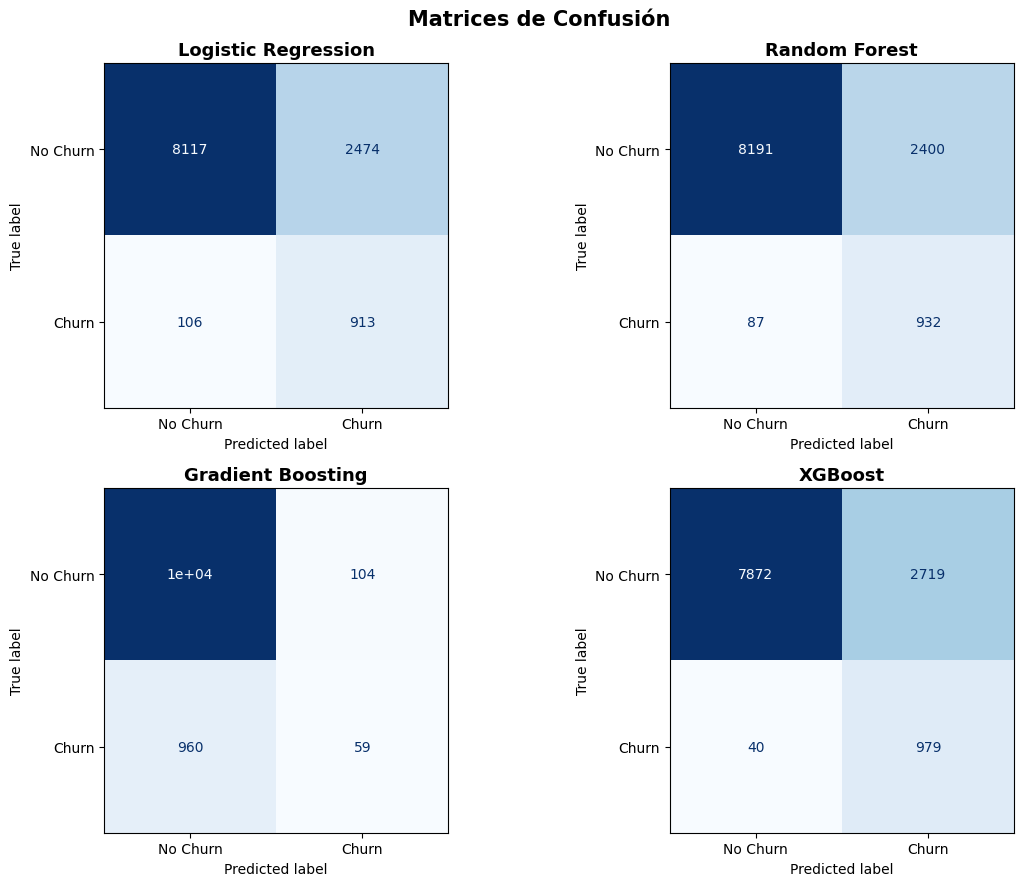

In [7]:
# ── 7. Matrices de confusión ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
for i, (nombre, r) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["No Churn","Churn"]).plot(
        ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(nombre, fontsize=13, fontweight="bold")
plt.suptitle("Matrices de Confusión", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


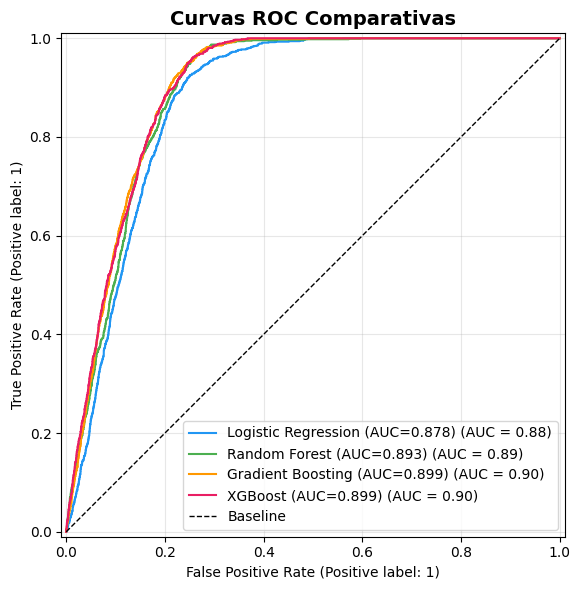

In [8]:
# ── 8. Curvas ROC ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colores = ["#2196F3","#4CAF50","#FF9800","#E91E63"]
for (nombre, r), color in zip(resultados.items(), colores):
    RocCurveDisplay.from_predictions(
        y_test, r["y_proba"],
        name=f"{nombre} (AUC={r['roc_auc']:.3f})", ax=ax, color=color)
ax.plot([0,1],[0,1],"k--", linewidth=1, label="Baseline")
ax.set_title("Curvas ROC Comparativas", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


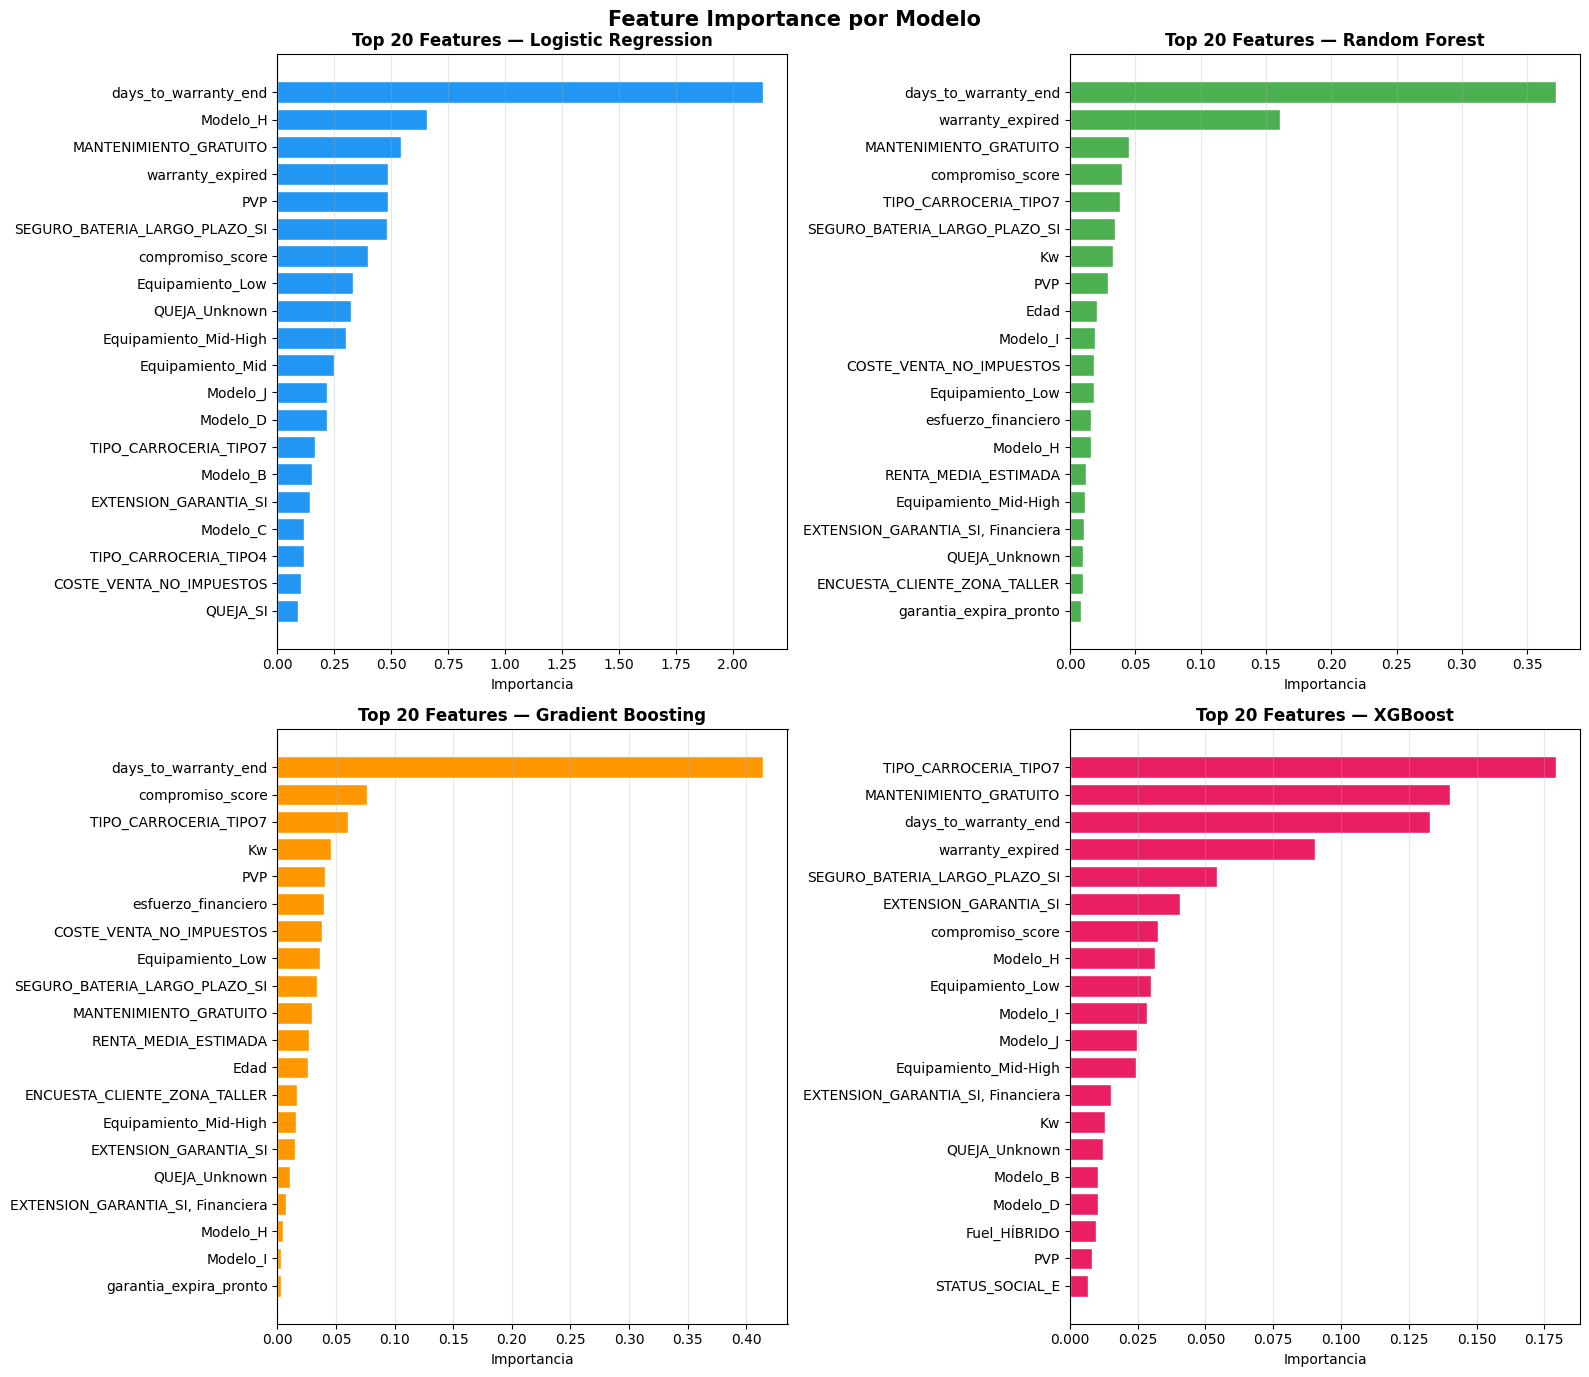

In [9]:
# ── 9. Feature Importance ─────────────────────────────────────────────────────
feature_names = X.columns.tolist()

def get_importances(nombre, estimator):
    model_step = estimator.named_steps["model"]
    imp = np.abs(model_step.coef_[0]) if hasattr(model_step, "coef_") else model_step.feature_importances_
    return pd.Series(imp, index=feature_names).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()
colores_fi = ["#2196F3","#4CAF50","#FF9800","#E91E63"]

for i, (nombre, r) in enumerate(resultados.items()):
    imp = get_importances(nombre, r["best_estimator"])
    axes[i].barh(imp.index[::-1], imp.values[::-1], color=colores_fi[i], edgecolor="white")
    axes[i].set_title(f"Top 20 Features — {nombre}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Importancia")
    axes[i].grid(axis="x", alpha=0.3)

plt.suptitle("Feature Importance por Modelo", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


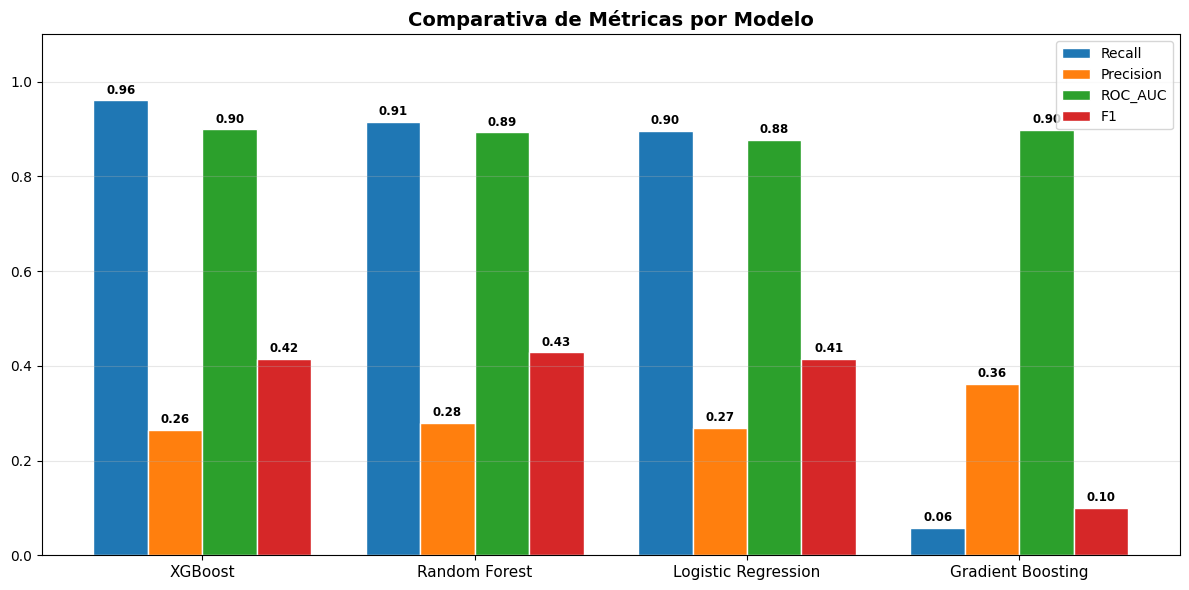

In [10]:
# ── 10. Comparativa métricas ──────────────────────────────────────────────────
metricas = ["Recall","Precision","ROC_AUC","F1"]
nombres  = df_res["Modelo"].tolist()
x        = np.arange(len(nombres))
width    = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
for j, metrica in enumerate(metricas):
    valores = df_res[metrica].tolist()
    bars = ax.bar(x + j*width, valores, width, label=metrica, edgecolor="white")
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(nombres, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title("Comparativa de Métricas por Modelo", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


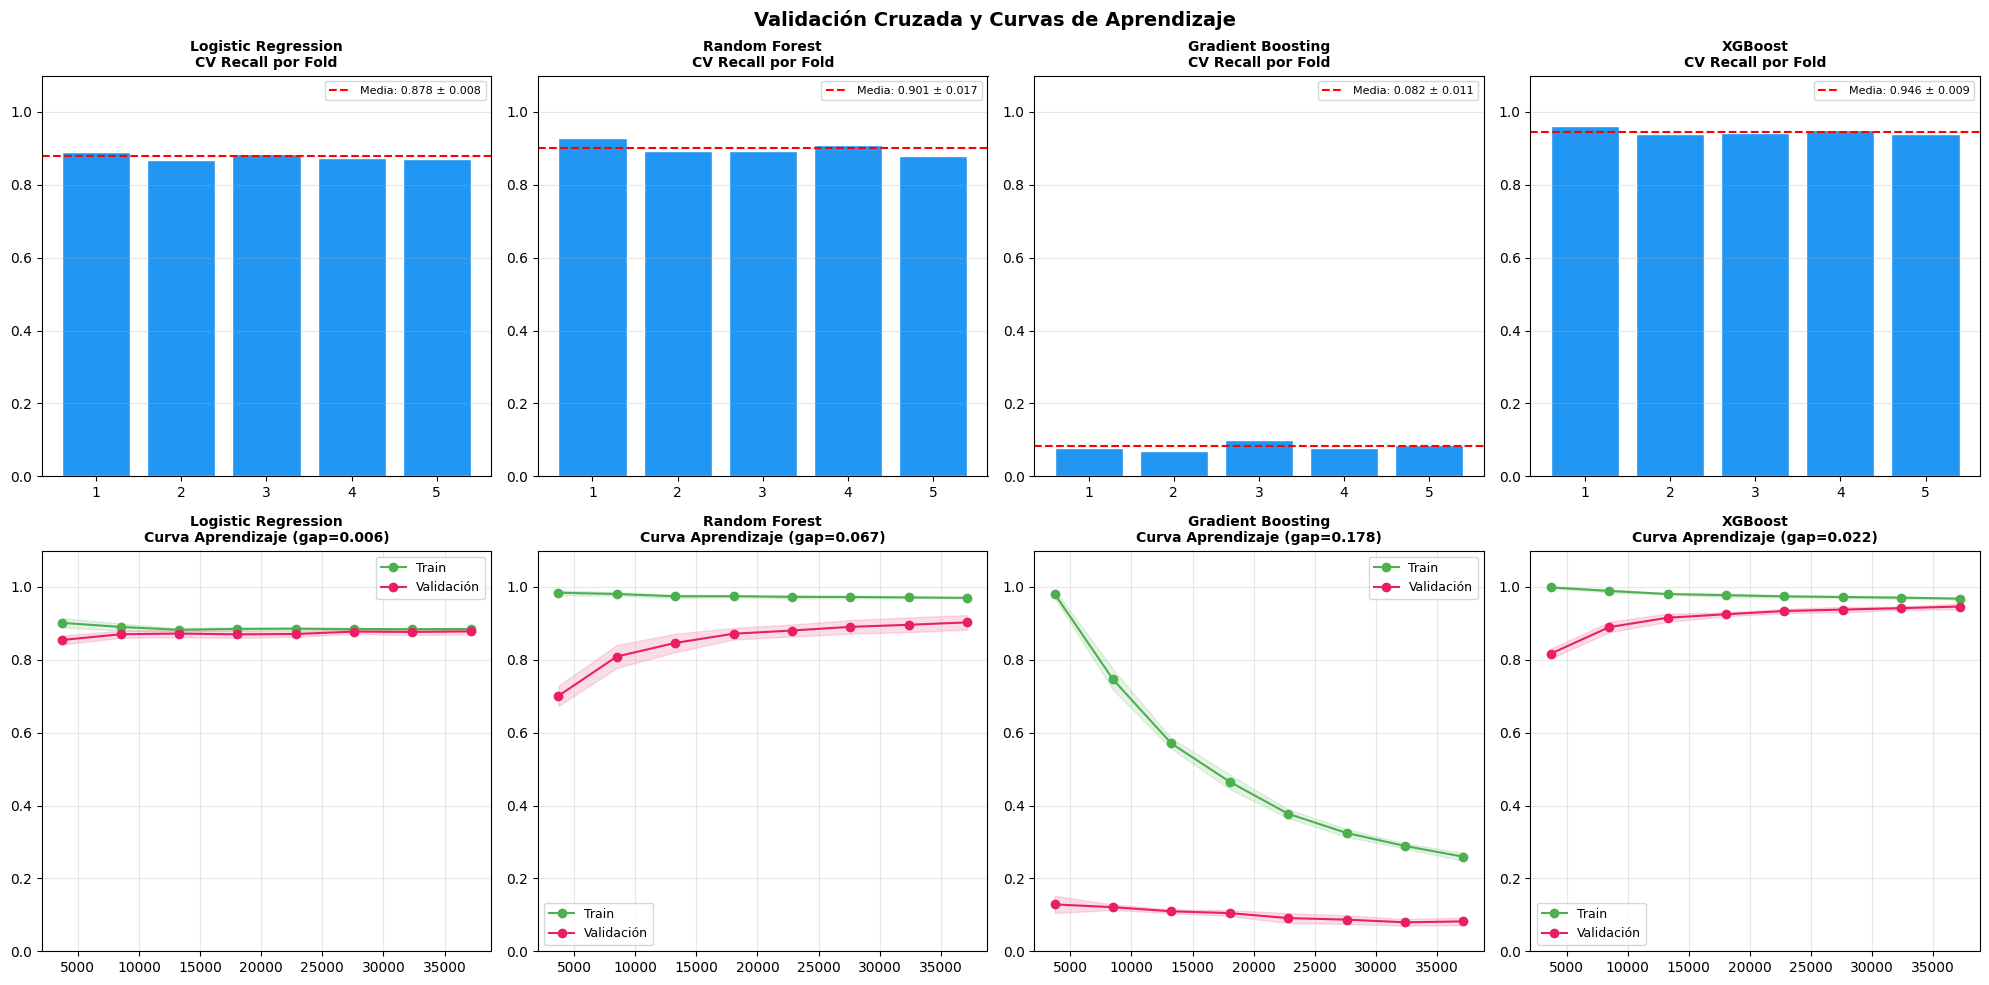


📊 Estabilidad CV:
  Logistic Regression       std=0.0082  🟢 Estable
  Random Forest             std=0.0170  🟢 Estable
  Gradient Boosting         std=0.0106  🟢 Estable
  XGBoost                   std=0.0090  🟢 Estable


In [11]:
# ── 11. Curvas de aprendizaje y CV por folds ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, (nombre, r) in enumerate(resultados.items()):
    # CV scores por fold
    ax_cv = axes[0, i]
    cv_scores = cross_val_score(r["best_estimator"], X_train, y_train, cv=5, scoring="recall", n_jobs=-1)
    ax_cv.bar(range(1,6), cv_scores, color="#2196F3", edgecolor="white")
    ax_cv.axhline(cv_scores.mean(), color="red", linestyle="--",
                  label=f"Media: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
    ax_cv.set_title(f"{nombre}\nCV Recall por Fold", fontsize=10, fontweight="bold")
    ax_cv.set_ylim(0, 1.1)
    ax_cv.legend(fontsize=8)
    ax_cv.grid(axis="y", alpha=0.3)

    # Curvas de aprendizaje
    ax_lc = axes[1, i]
    train_sizes, train_scores, val_scores = learning_curve(
        r["best_estimator"], X_train, y_train,
        cv=5, scoring="recall", n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8), shuffle=True, random_state=42
    )
    tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
    vm, vs = val_scores.mean(axis=1),   val_scores.std(axis=1)

    ax_lc.plot(train_sizes, tm, "o-", color="#4CAF50", label="Train")
    ax_lc.fill_between(train_sizes, tm-ts, tm+ts, alpha=0.15, color="#4CAF50")
    ax_lc.plot(train_sizes, vm, "o-", color="#E91E63", label="Validación")
    ax_lc.fill_between(train_sizes, vm-vs, vm+vs, alpha=0.15, color="#E91E63")
    ax_lc.set_title(f"{nombre}\nCurva Aprendizaje (gap={tm[-1]-vm[-1]:.3f})", fontsize=10, fontweight="bold")
    ax_lc.set_ylim(0, 1.1)
    ax_lc.legend(fontsize=9)
    ax_lc.grid(alpha=0.3)

plt.suptitle("Validación Cruzada y Curvas de Aprendizaje", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 Estabilidad CV:")
for nombre, r in resultados.items():
    cv_s = cross_val_score(r["best_estimator"], X_train, y_train, cv=5, scoring="recall", n_jobs=-1)
    estado = "🟢 Estable" if cv_s.std() < 0.02 else "🟡 Aceptable" if cv_s.std() < 0.05 else "🔴 Inestable"
    print(f"  {nombre:<25} std={cv_s.std():.4f}  {estado}")


In [12]:
# ── 12. Mejor modelo ─────────────────────────────────────────────────────────
candidatos = df_res[df_res["ROC_AUC"] >= 0.75].sort_values("Recall", ascending=False)
mejor = candidatos.iloc[0]["Modelo"]
r = resultados[mejor]

print(f"🏆 Mejor modelo: {mejor}")
print(f"   Recall:    {r['recall']:.4f}  → detecta {r['recall']*100:.1f} de cada 100 churners")
print(f"   Precision: {r['precision']:.4f}  → {r['precision']*100:.1f} de cada 100 alertas son reales")
print(f"   ROC-AUC:   {r['roc_auc']:.4f}")
print(f"   F1:        {r['f1']:.4f}")
print(f"\n   Hiperparámetros:")
for k, v in r["best_params"].items():
    print(f"     {k}: {v}")


🏆 Mejor modelo: XGBoost
   Recall:    0.9607  → detecta 96.1 de cada 100 churners
   Precision: 0.2647  → 26.5 de cada 100 alertas son reales
   ROC-AUC:   0.8992
   F1:        0.4151

   Hiperparámetros:
     model__colsample_bytree: 1.0
     model__learning_rate: 0.05
     model__max_depth: 4
     model__n_estimators: 200


In [13]:
# ── 13. Guardar modelo ganador a disco ────────────────────────────────────────
import joblib

modelo_final  = resultados[mejor]["best_estimator"]
cols_train    = X.columns.tolist()

joblib.dump(modelo_final, "modelo_churn.pkl")
pd.Series(cols_train).to_csv("cols_train.csv", index=False)
pd.Series(r["best_params"]).to_csv("best_params.csv", header=["valor"])

print(f"✅ modelo_churn.pkl guardado — modelo: {mejor}")
print(f"✅ cols_train.csv  guardado — {len(cols_train)} features")
print(f"✅ best_params.csv guardado")
print(f"\nRecall Test:  {r['recall']:.4f}")
print(f"ROC-AUC Test: {r['roc_auc']:.4f}")


✅ modelo_churn.pkl guardado — modelo: XGBoost
✅ cols_train.csv  guardado — 72 features
✅ best_params.csv guardado

Recall Test:  0.9607
ROC-AUC Test: 0.8992
